# What Is LLM Inference?

**Who this is for:** Engineers from a Platform / DevOps / SRE background who are new to ML.  
Every concept maps to something you already know.

**Goal:** Understand what inference *is* and what happens end-to-end when an LLM generates text.  
No optimizations yet — just the baseline mechanics.

**Time:** ~20 minutes interactive

## The Big Picture

**Training** teaches a model to predict the next word. **Inference** is using that trained model to actually generate text.

Think of it like compiling vs. running:

| ML Term | Infra Analogy |
|---|---|
| Training | Building/compiling the binary (expensive, done once) |
| Model weights | The compiled binary artifact sitting on disk |
| Inference | Running that binary to serve requests |

When you call an LLM API, you are doing inference — loading the model weights into GPU memory and running input through it to produce output.

Every single inference request follows three stages:

```
Text In → [Tokenize] → [Forward Pass (the model)] → [Decode] → Text Out
```

This notebook walks through each stage with real code.

In [1]:
# Setup
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# We'll use GPT-2 (124M params) -- small enough to run on CPU
MODEL_NAME = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()  # inference mode -- disables training-only behavior like dropout

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")

/home/nvidia/src/github.com/elizabetht/100-days-of-inference/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10410.84it/s]

Model: gpt2
Parameters: 124,439,808
Vocabulary size: 50,257 tokens


## Stage 1: Tokenization — Text to Numbers

Models don't read text. They work with integers called **tokens**.

A tokenizer is a codec — it converts between human-readable text and the integer sequences the model understands. Same idea as a protobuf serializer or JSON encoder.

```
"Hello world" → [15496, 995]  (encode)
[15496, 995]  → "Hello world"  (decode)
```

Tokens are not words. They are chunks of text — sometimes whole words, sometimes parts of words, sometimes single characters.

In [2]:
# Tokenize a prompt and see what comes out
prompt = "Kubernetes pods are scheduled by the"

token_ids = tokenizer.encode(prompt)
tokens = [tokenizer.decode(tid) for tid in token_ids]

print(f"Input text:  {prompt!r}")
print(f"Token IDs:   {token_ids}")
print(f"Tokens:      {tokens}")
print(f"Token count: {len(token_ids)}")
print()

# Show the mapping side by side
for tid, tok in zip(token_ids, tokens):
    print(f"  {tid:>6d} → {tok!r}")

Input text:  'Kubernetes pods are scheduled by the'
Token IDs:   [42, 18478, 3262, 274, 37185, 389, 7530, 416, 262]
Tokens:      ['K', 'uber', 'net', 'es', ' pods', ' are', ' scheduled', ' by', ' the']
Token count: 9

      42 → 'K'
   18478 → 'uber'
    3262 → 'net'
     274 → 'es'
   37185 → ' pods'
     389 → ' are'
    7530 → ' scheduled'
     416 → ' by'
     262 → ' the'


In [3]:
# Different text, different tokenizations
# Notice: common words get one token, rare words get split into pieces
examples = [
    "the",
    "Kubernetes",
    "autoscaler",
    "NVIDIA",
    "192.168.1.1",
]

for text in examples:
    ids = tokenizer.encode(text)
    pieces = [tokenizer.decode(i) for i in ids]
    print(f"  {text:<20s} → {len(ids)} token(s): {pieces}")

  the                  → 1 token(s): ['the']
  Kubernetes           → 4 token(s): ['K', 'uber', 'net', 'es']
  autoscaler           → 4 token(s): ['aut', 'os', 'cal', 'er']
  NVIDIA               → 1 token(s): ['NVIDIA']
  192.168.1.1          → 7 token(s): ['192', '.', '168', '.', '1', '.', '1']


**Key takeaway:** Tokenization determines how many "steps" the model needs to process your input.  
More tokens = more compute. This is why API pricing is per-token.

## Stage 2: The Forward Pass — What the Model Actually Computes

The forward pass is the core of inference. You feed token IDs in, and the model outputs a **probability distribution over every possible next token**.

This output is called **logits** — a vector of raw scores, one per vocabulary entry.

```
Token IDs [15496, 995] → Model → Logits [score_for_token_0, score_for_token_1, ..., score_for_token_50256]
```

The model does not return text. It returns a list of 50,257 scores (GPT-2's vocabulary size) representing how likely each token is to come next.

In [4]:
# Run one forward pass and look at the raw output
prompt = "Kubernetes pods are scheduled by the"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():  # no need to track gradients during inference
    outputs = model(**inputs)

# outputs.logits shape: [batch_size, sequence_length, vocab_size]
logits = outputs.logits
print(f"Input tokens:  {inputs['input_ids'].shape[1]}")
print(f"Logits shape:  {logits.shape}")
print(f"  → batch=1, seq_len={logits.shape[1]}, vocab={logits.shape[2]}")
print()

# We care about the LAST position -- that's the prediction for the NEXT token
next_token_logits = logits[0, -1, :]  # shape: [vocab_size]
print(f"Logits for next token: {next_token_logits.shape[0]} scores")
print(f"  min={next_token_logits.min():.2f}, max={next_token_logits.max():.2f}")

Input tokens:  9
Logits shape:  torch.Size([1, 9, 50257])
  → batch=1, seq_len=9, vocab=50257

Logits for next token: 50257 scores
  min=-125.86, max=-98.24


In [5]:
# Convert logits to probabilities and see the top predictions
import torch.nn.functional as F

probs = F.softmax(next_token_logits, dim=-1)

# Top 10 most likely next tokens
top_probs, top_ids = torch.topk(probs, k=10)

print(f"Prompt: {prompt!r}")
print(f"\nTop 10 predictions for the next token:\n")
for prob, tid in zip(top_probs, top_ids):
    token_text = tokenizer.decode(tid)
    print(f"  {prob:>6.2%}  →  {token_text!r}")

Prompt: 'Kubernetes pods are scheduled by the'

Top 10 predictions for the next token:

  20.02%  →  ' end'
   5.59%  →  ' time'
   2.03%  →  ' same'
   1.31%  →  ' start'
   1.29%  →  ' day'
   1.20%  →  ' company'
   1.06%  →  ' next'
   0.79%  →  ' beginning'
   0.69%  →  ' server'
   0.62%  →  ' following'


**Key takeaway:** A single forward pass gives you predictions for one token position. The model doesn't generate a whole response at once — it produces one token's worth of probabilities per pass.

## Stage 3: Decoding — Picking the Next Token

The model gave us 50,257 scores. Now we need to pick one token. This is **decoding** (also called **sampling**).

There are different strategies:

| Strategy | How it works | Analogy |
|---|---|---|
| **Greedy** | Always pick the highest-probability token | Round-robin to the fastest server |
| **Top-k** | Pick randomly from the top k most likely tokens | Load balance across your k healthiest nodes |
| **Temperature** | Scale probabilities before sampling (higher = more random) | Jitter added to avoid thundering herd |

Let's see greedy decoding — the simplest approach.

In [6]:
# Greedy decoding: just pick the most likely token
next_token_id = torch.argmax(next_token_logits).item()
next_token_text = tokenizer.decode(next_token_id)

print(f"Prompt:     {prompt!r}")
print(f"Next token: {next_token_text!r} (id={next_token_id})")
print(f"Full text:  {prompt + next_token_text!r}")

Prompt:     'Kubernetes pods are scheduled by the'
Next token: ' end' (id=886)
Full text:  'Kubernetes pods are scheduled by the end'


In [7]:
# Temperature affects randomness
# Low temperature → model is more confident (peaky distribution)
# High temperature → model is more random (flat distribution)

for temp in [0.1, 0.5, 1.0, 2.0]:
    scaled = next_token_logits / temp
    p = F.softmax(scaled, dim=-1)
    top_p, top_i = torch.topk(p, k=5)
    tokens_str = ", ".join(f"{tokenizer.decode(i)!r} ({v:.1%})" for v, i in zip(top_p, top_i))
    print(f"  temp={temp:.1f}  →  {tokens_str}")

  temp=0.1  →  ' end' (100.0%), ' time' (0.0%), ' same' (0.0%), ' start' (0.0%), ' day' (0.0%)
  temp=0.5  →  ' end' (89.3%), ' time' (7.0%), ' same' (0.9%), ' start' (0.4%), ' day' (0.4%)
  temp=1.0  →  ' end' (20.0%), ' time' (5.6%), ' same' (2.0%), ' start' (1.3%), ' day' (1.3%)
  temp=2.0  →  ' end' (0.6%), ' time' (0.3%), ' same' (0.2%), ' start' (0.1%), ' day' (0.1%)


## Putting It All Together: The Autoregressive Loop

LLMs generate text **one token at a time** in a loop:

```
1. Tokenize the prompt
2. Forward pass → get logits for next token
3. Pick a token (decode/sample)
4. Append that token to the sequence
5. Go to step 2 (repeat until done)
```

This is called **autoregressive generation** — each token depends on all previous tokens.

It's like a pipeline where the output of each stage feeds back as input to the next iteration.

In [8]:
# The full inference loop, step by step
# No library magic -- just the raw mechanics

prompt = "The server crashed because"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
generated = input_ids.clone()

NUM_TOKENS = 20

print(f"Prompt: {prompt!r}\n")
print("Generating tokens one at a time:\n")

for step in range(NUM_TOKENS):
    # Step 1: Forward pass -- feed the ENTIRE sequence so far
    with torch.no_grad():
        outputs = model(generated)

    # Step 2: Get logits for the last position
    next_logits = outputs.logits[0, -1, :]

    # Step 3: Greedy decode -- pick the most likely token
    next_id = torch.argmax(next_logits).unsqueeze(0).unsqueeze(0)

    # Step 4: Append to sequence
    generated = torch.cat([generated, next_id], dim=1)

    # Show progress
    new_token = tokenizer.decode(next_id[0])
    total_len = generated.shape[1]
    print(f"  step {step+1:>2d} | seq_len={total_len:>3d} | token={new_token!r}")

print(f"\nFinal output: {tokenizer.decode(generated[0])}")

Prompt: 'The server crashed because'

Generating tokens one at a time:

  step  1 | seq_len=  5 | token=' of'
  step  2 | seq_len=  6 | token=' a'
  step  3 | seq_len=  7 | token=' bug'
  step  4 | seq_len=  8 | token=' in'
  step  5 | seq_len=  9 | token=' the'
  step  6 | seq_len= 10 | token=' server'
  step  7 | seq_len= 11 | token="'s"
  step  8 | seq_len= 12 | token=' configuration'
  step  9 | seq_len= 13 | token=' file'
  step 10 | seq_len= 14 | token='.'
  step 11 | seq_len= 15 | token='\n'
  step 12 | seq_len= 16 | token='\n'
  step 13 | seq_len= 17 | token='The'
  step 14 | seq_len= 18 | token=' server'
  step 15 | seq_len= 19 | token=' crashed'
  step 16 | seq_len= 20 | token=' because'
  step 17 | seq_len= 21 | token=' of'
  step 18 | seq_len= 22 | token=' a'
  step 19 | seq_len= 23 | token=' bug'
  step 20 | seq_len= 24 | token=' in'

Final output: The server crashed because of a bug in the server's configuration file.

The server crashed because of a bug in


Notice how seq_len grows by 1 each step. At every step, the model re-reads the *entire* sequence to predict just one new token. This is the fundamental cost of autoregressive generation.

## What Does Inference Cost?

Let's measure how long each step takes as the sequence grows.

In [9]:
import time

prompt = "Deploying a containerized application to production requires"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
generated = input_ids.clone()

NUM_TOKENS = 40
step_times = []

for step in range(NUM_TOKENS):
    start = time.perf_counter()
    with torch.no_grad():
        outputs = model(generated)
    next_id = torch.argmax(outputs.logits[0, -1, :]).unsqueeze(0).unsqueeze(0)
    generated = torch.cat([generated, next_id], dim=1)
    elapsed = time.perf_counter() - start
    step_times.append(elapsed)

print(f"Generated: {tokenizer.decode(generated[0])}")
print(f"\nTiming per step:")
print(f"  First token:  {step_times[0]*1000:.1f} ms")
print(f"  Last token:   {step_times[-1]*1000:.1f} ms")
print(f"  Total time:   {sum(step_times)*1000:.1f} ms")
print(f"  Avg per token: {sum(step_times)/len(step_times)*1000:.1f} ms")

Generated: Deploying a containerized application to production requires a lot of work.

The following is a list of the most common tasks that you'll need to do to deploy a containerized application to production:

Deploying a containerized application

Timing per step:
  First token:  64.0 ms
  Last token:   147.4 ms
  Total time:   4623.7 ms
  Avg per token: 115.6 ms


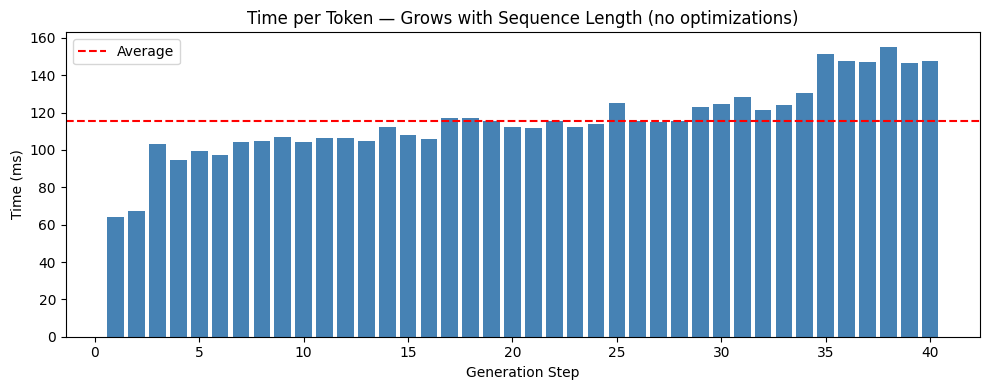

In [10]:
# Visualize: each step gets slower as the sequence grows
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, NUM_TOKENS + 1), [t * 1000 for t in step_times], color="steelblue")
ax.set_xlabel("Generation Step")
ax.set_ylabel("Time (ms)")
ax.set_title("Time per Token — Grows with Sequence Length (no optimizations)")
ax.axhline(y=sum(step_times)/len(step_times)*1000, color="red", linestyle="--", label="Average")
ax.legend()
plt.tight_layout()
plt.show()

Each step re-processes the entire sequence from scratch. As the sequence grows, each step takes longer. This is the naive baseline — later days will cover optimizations like the KV cache that fix this.

## Using the Library's Built-in Generate

The loop above is what `model.generate()` does under the hood. Let's confirm we get the same result.

In [11]:
# model.generate() wraps the same loop with optimizations and options
prompt = "Deploying a containerized application to production requires"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=False,  # greedy, same as our argmax
    )

print(tokenizer.decode(output_ids[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Deploying a containerized application to production requires a lot of work.

The following is a list of the most common tasks that you'll need to do to deploy a containerized application to production:

Deploying a containerized application


## Recap

Inference is the process of running a trained model to generate output. For LLMs, every request follows the same path:

| Stage | What happens | Cost driver |
|---|---|---|
| **Tokenize** | Text → integer IDs | Negligible |
| **Forward pass** | IDs → probability scores (logits) | Model size x sequence length |
| **Decode** | Pick one token from the scores | Negligible |
| **Loop** | Repeat forward+decode for each output token | Number of output tokens |

The fundamental cost: the model must re-read the entire sequence for every new token it generates.  
Everything in inference optimization (KV caching, batching, speculative decoding) exists to reduce this cost.